# Part 1 - Single-Objective Clustering

This notebook presents the Part 1 pipeline in clean, step-by-step cells.
It uses your existing implementation from part1_clustering.py.

## 1) Setup

In [23]:
from pathlib import Path
import os
import sys
import time
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "part1_clustering.py").exists():
    PROJECT_ROOT = Path("/home/hafeez/tdm/project_2")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import part1_clustering as p1
print(f"Project root: {PROJECT_ROOT}")

Project root: /home/hafeez/tdm/project_2


### Plot Helpers

These helpers render figures directly inline so each analysis step can show its own chart right away.

In [24]:
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import display, Markdown, Image
from sklearn.cluster import KMeans

def show_figure_inline(fig, title):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    display(Markdown(f"### {title}"))
    display(Image(data=buf.getvalue()))

## 2) Domain Description

In [25]:
p1.step1_domain()

STEP 1 – Domain: Healthcare
Clustering is highly useful in healthcare because patient data
is often unlabelled and heterogeneous. It helps to:
  • Stratify patients into risk groups (e.g. diabetes severity).
  • Discover disease subtypes from genomic / clinical features.
  • Support personalised treatment planning.
  • Detect anomalies such as rare disease patterns.



## 3) Dataset Loading

In [26]:
df_pima, df_bc = p1.step2_load_datasets()
display(Markdown("### Pima Diabetes Preview"))
display(df_pima.head())
display(Markdown("### Breast Cancer Preview"))
display(df_bc.head())


STEP 2 – Select Two Datasets
  Pima Diabetes loaded from URL: (768, 9)
  Breast Cancer loaded from sklearn: (569, 30)


### Pima Diabetes Preview

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Breast Cancer Preview

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 4) Preprocessing

In [27]:
X_pima, X_pima_pca, X_bc, X_bc_pca = p1.step3_preprocessing(df_pima, df_bc)
print("Scaled shapes:")
print("  Pima:", X_pima.shape)
print("  Breast Cancer:", X_bc.shape)


STEP 3 – Data Preprocessing
Scaled shapes:
  Pima: (768, 8)
  Breast Cancer: (569, 30)


## 5) Elbow-Based Cluster Count

In [28]:
k_pima, k_bc = p1.step4_determine_k(X_pima, X_bc)
print(f"Selected k values -> Pima: {k_pima}, Breast Cancer: {k_bc}")


STEP 4 – Determine Number of Clusters (Elbow Method)
  Pima Diabetes k=4, Breast Cancer k=4
Selected k values -> Pima: 4, Breast Cancer: 4


### Elbow Curves (Step 5 Context)

This plot is shown right after selecting k so the choice is immediately visible.

### Elbow Curves

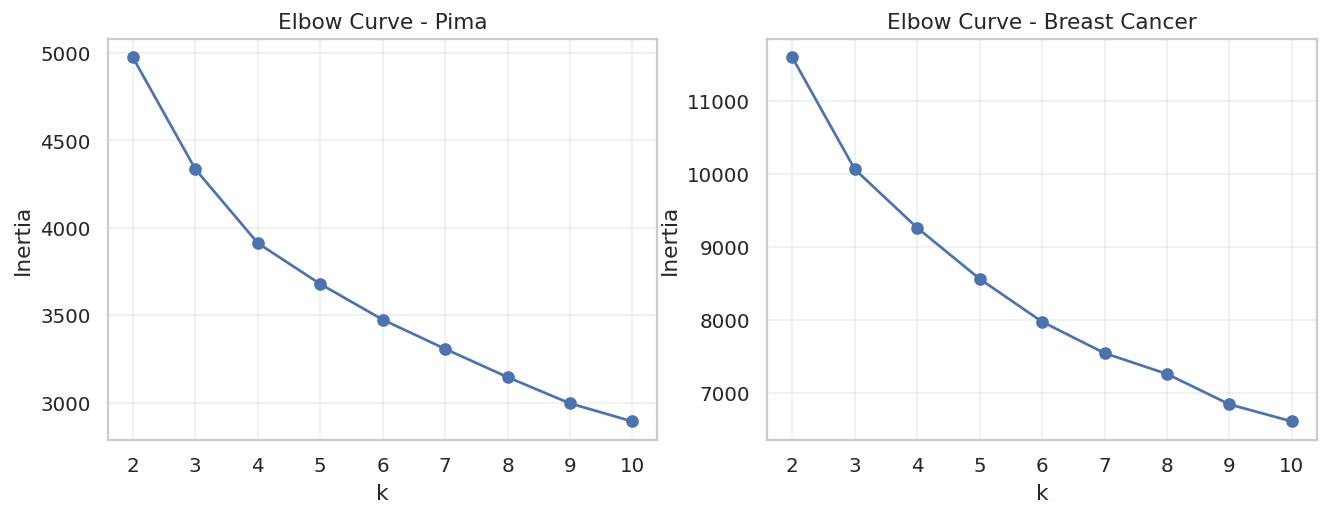

In [29]:
k_range = list(range(2, 11))
pima_inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pima).inertia_ for k in k_range]
bc_inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_bc).inertia_ for k in k_range]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, pima_inertias, marker="o")
axes[0].set_title("Elbow Curve - Pima")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, bc_inertias, marker="o")
axes[1].set_title("Elbow Curve - Breast Cancer")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Inertia")
axes[1].grid(alpha=0.3)

show_figure_inline(fig, "Elbow Curves")

## 6) K-Means, DBSCAN, and Agglomerative Runs

In [30]:
start = time.time()
km_pima, km_bc = p1.step5_kmeans(X_pima, X_pima_pca, k_pima, X_bc, X_bc_pca, k_bc)
db_pima, db_bc = p1.step6_dbscan(X_pima, X_pima_pca, X_bc, X_bc_pca)
agg_pima, agg_bc = p1.step6b_agglomerative(X_pima, k_pima, X_bc, k_bc)
print(f"Computation time: {time.time() - start:.2f} seconds")


STEP 5 – K-Means Clustering (5 runs)

STEP 6 – DBSCAN Clustering (5 settings)

STEP 6B – Agglomerative Clustering (5 settings)
Computation time: 1.48 seconds


### Cluster Visualizations (Step 6)

These plots use the same run settings and show the best run/setting for quick visual interpretation.

### K-Means Cluster Visualizations (PCA)

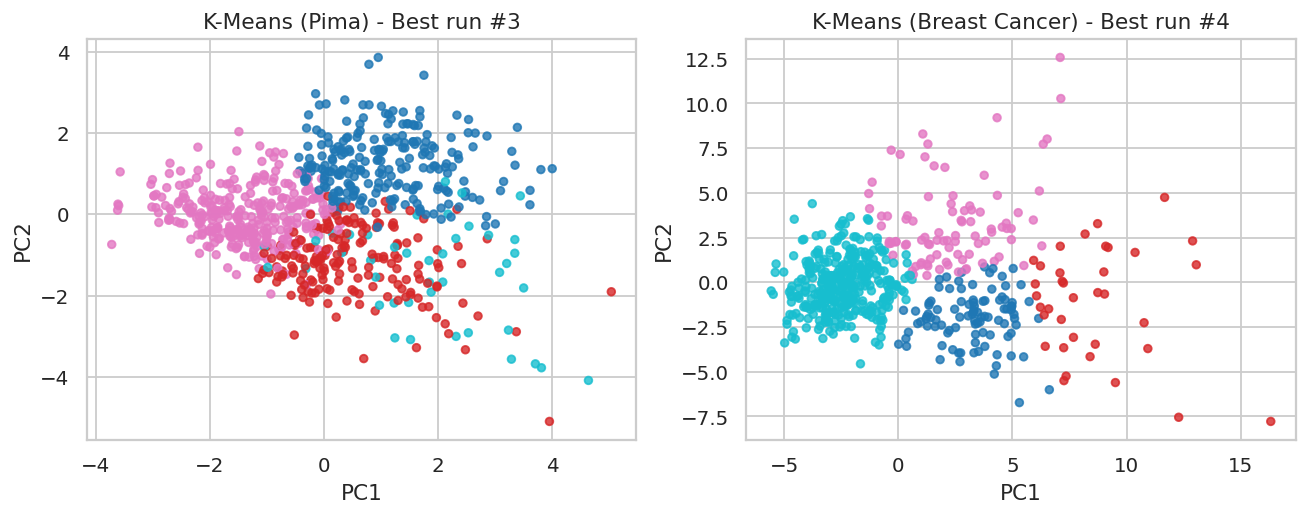

### DBSCAN Cluster Visualizations (PCA)

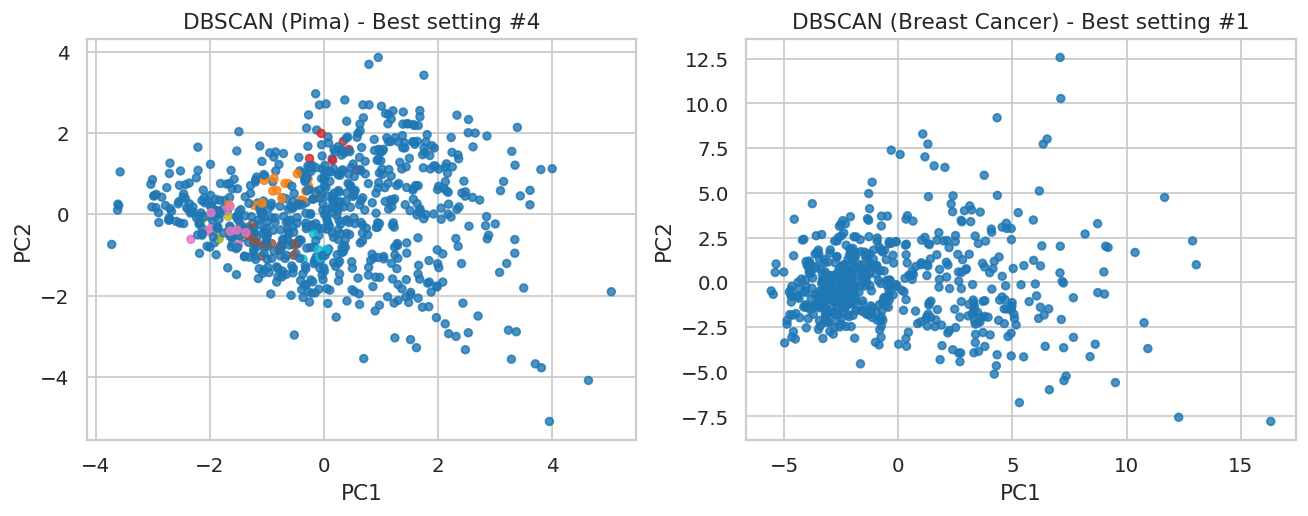

In [31]:
# K-Means cluster visualization (best silhouette run)
km_scores_pima_inline, km_labels_pima_inline = p1.run_kmeans(X_pima, k_pima)
km_scores_bc_inline, km_labels_bc_inline = p1.run_kmeans(X_bc, k_bc)
best_km_pima_idx = int(np.argmax(km_scores_pima_inline))
best_km_bc_idx = int(np.argmax(km_scores_bc_inline))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(
    X_pima_pca[:, 0], X_pima_pca[:, 1],
    c=km_labels_pima_inline[best_km_pima_idx], cmap="tab10", s=18, alpha=0.8
)
axes[0].set_title(f"K-Means (Pima) - Best run #{best_km_pima_idx + 1}")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(
    X_bc_pca[:, 0], X_bc_pca[:, 1],
    c=km_labels_bc_inline[best_km_bc_idx], cmap="tab10", s=18, alpha=0.8
)
axes[1].set_title(f"K-Means (Breast Cancer) - Best run #{best_km_bc_idx + 1}")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

show_figure_inline(fig, "K-Means Cluster Visualizations (PCA)")

# DBSCAN cluster visualization (best parameter setting)
db_scores_pima_inline, db_labels_pima_inline = p1.run_dbscan(X_pima, p1.DBSCAN_PARAMS)
db_scores_bc_inline, db_labels_bc_inline = p1.run_dbscan(X_bc, p1.DBSCAN_PARAMS)
best_db_pima_idx = int(np.argmax(db_scores_pima_inline))
best_db_bc_idx = int(np.argmax(db_scores_bc_inline))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(
    X_pima_pca[:, 0], X_pima_pca[:, 1],
    c=db_labels_pima_inline[best_db_pima_idx], cmap="tab10", s=18, alpha=0.8
)
axes[0].set_title(f"DBSCAN (Pima) - Best setting #{best_db_pima_idx + 1}")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(
    X_bc_pca[:, 0], X_bc_pca[:, 1],
    c=db_labels_bc_inline[best_db_bc_idx], cmap="tab10", s=18, alpha=0.8
)
axes[1].set_title(f"DBSCAN (Breast Cancer) - Best setting #{best_db_bc_idx + 1}")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

show_figure_inline(fig, "DBSCAN Cluster Visualizations (PCA)")

## 7) Evaluation and Statistical Tests

In [32]:
p1.step7_evaluation(km_pima, db_pima, agg_pima, km_bc, db_bc, agg_bc)
p1.step8_statistical_test(km_pima, db_pima, agg_pima, km_bc, db_bc, agg_bc)
p1.step9_sensitivity(db_pima, db_bc)


STEP 7 – Clustering Evaluation (Silhouette Score Table)
Pima -> K-Means Mean: 0.1874 | DBSCAN Mean: -0.5574 | Agglomerative Mean: 0.3006
BC   -> K-Means Mean: 0.2545 | DBSCAN Mean: -1.0000 | Agglomerative Mean: 0.3854

STEP 8 – Statistical Significance Testing (Non-Parametric)

--- Statistical Tests: Pima Diabetes ---
  Wilcoxon Test: p-value = 0.1250 (Not Significant)
  Friedman Test: p-value = 0.0743 (Not Significant)

--- Statistical Tests: Breast Cancer ---
  Wilcoxon Test: p-value = 0.0625 (Not Significant)
  Friedman Test: p-value = 0.0067 (Significant)

STEP 9 – Parameter Sensitivity Analysis
Observations: Smaller ε increases noise; Moderate ε (0.5-0.8) balances density.


### Evaluation Plots and Verification (Step 7)

These figures summarize metric behavior right after evaluation and testing.

### Silhouette Score Comparison

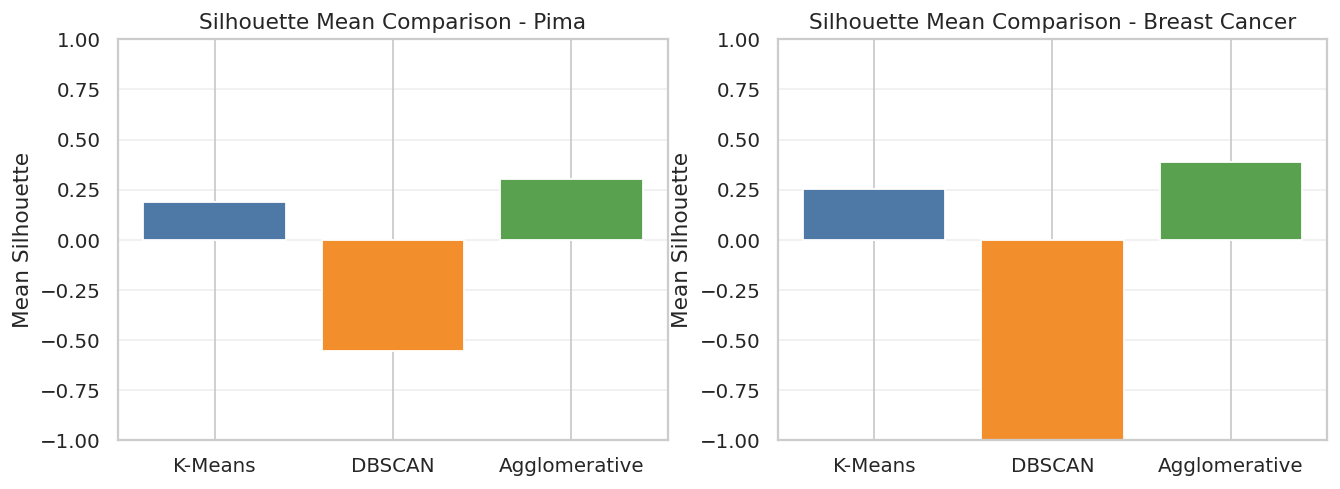

### DBSCAN Sensitivity

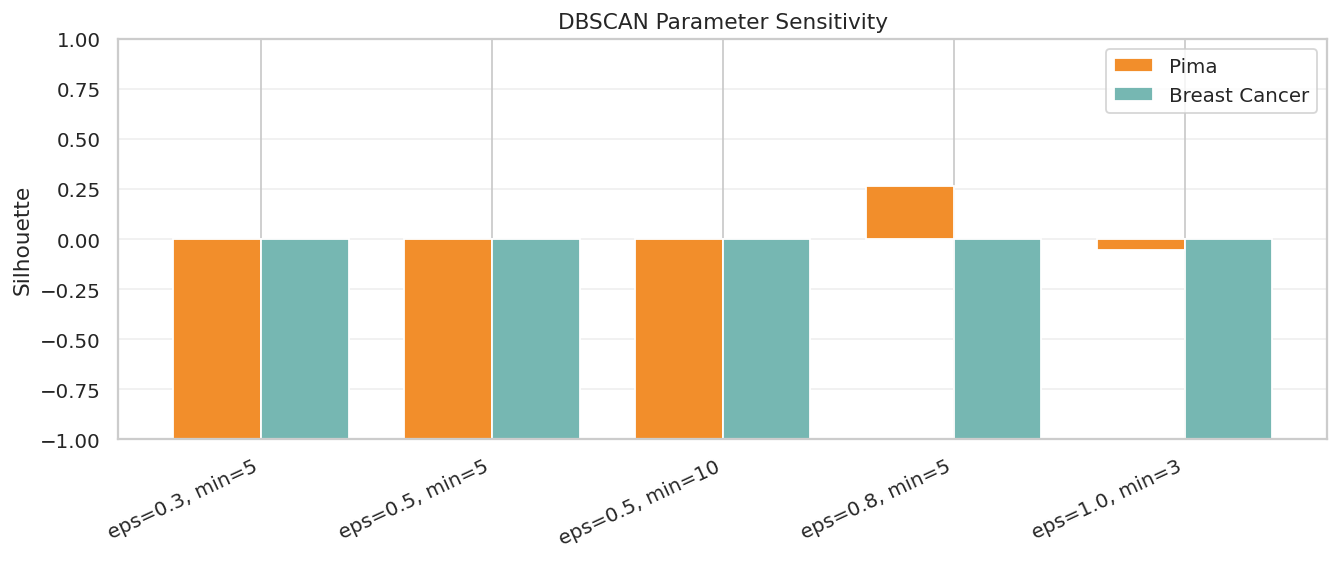

### Verification Results

,check,passed
0,km_pima_len_5,True
1,km_bc_len_5,True
2,db_pima_len_5,True
3,db_bc_len_5,True
4,agg_pima_len_5,True
5,agg_bc_len_5,True
6,no_nan,True
7,silhouette_range_valid,True


All output checks passed.


In [33]:
# Silhouette comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ["K-Means", "DBSCAN", "Agglomerative"]

pima_means = [np.mean(km_pima), np.mean(db_pima), np.mean(agg_pima)]
bc_means = [np.mean(km_bc), np.mean(db_bc), np.mean(agg_bc)]

axes[0].bar(labels, pima_means, color=["#4e79a7", "#f28e2b", "#59a14f"])
axes[0].set_title("Silhouette Mean Comparison - Pima")
axes[0].set_ylabel("Mean Silhouette")
axes[0].set_ylim(-1, 1)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(labels, bc_means, color=["#4e79a7", "#f28e2b", "#59a14f"])
axes[1].set_title("Silhouette Mean Comparison - Breast Cancer")
axes[1].set_ylabel("Mean Silhouette")
axes[1].set_ylim(-1, 1)
axes[1].grid(axis="y", alpha=0.3)

show_figure_inline(fig, "Silhouette Score Comparison")

# DBSCAN sensitivity
param_labels = [f"eps={p['eps']}, min={p['min_samples']}" for p in p1.DBSCAN_PARAMS]
x = np.arange(len(param_labels))
w = 0.38

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w / 2, db_pima, width=w, label="Pima", color="#f28e2b")
ax.bar(x + w / 2, db_bc, width=w, label="Breast Cancer", color="#76b7b2")
ax.set_xticks(x)
ax.set_xticklabels(param_labels, rotation=25, ha="right")
ax.set_ylabel("Silhouette")
ax.set_ylim(-1, 1)
ax.set_title("DBSCAN Parameter Sensitivity")
ax.grid(axis="y", alpha=0.3)
ax.legend()

show_figure_inline(fig, "DBSCAN Sensitivity")

# Output verification checks
checks = {
    "km_pima_len_5": len(km_pima) == 5,
    "km_bc_len_5": len(km_bc) == 5,
    "db_pima_len_5": len(db_pima) == 5,
    "db_bc_len_5": len(db_bc) == 5,
    "agg_pima_len_5": len(agg_pima) == 5,
    "agg_bc_len_5": len(agg_bc) == 5,
    "no_nan": not np.isnan(
        np.array(km_pima + km_bc + db_pima + db_bc + agg_pima + agg_bc, dtype=float)
    ).any(),
    "silhouette_range_valid": all(
        -1.0 <= v <= 1.0
        for v in (km_pima + km_bc + db_pima + db_bc + agg_pima + agg_bc)
    ),
}

verification_df = pd.DataFrame(
    {"check": list(checks.keys()), "passed": list(checks.values())}
)
display(Markdown("### Verification Results"))
display(verification_df)
if verification_df["passed"].all():
    print("All output checks passed.")
else:
    print("Some checks failed. Inspect the table above.")

## 8) Compact Score Summary

In [34]:
summary = pd.DataFrame(
    {
        "KMeans Mean": [np.mean(km_pima), np.mean(km_bc)],
        "DBSCAN Mean": [np.mean(db_pima), np.mean(db_bc)],
        "Agglomerative Mean": [np.mean(agg_pima), np.mean(agg_bc)],
    },
    index=["Pima Diabetes", "Breast Cancer"],
)
display(summary.round(4))

,KMeans Mean,DBSCAN Mean,Agglomerative Mean
Pima Diabetes,0.1874,-0.5574,0.3006
Breast Cancer,0.2545,-1.0000,0.3854
